In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [32]:
S0 = 100
K = 100
r = 0.04
sigma = 0.25
T = 3
R = 500000


In [33]:
def simulate_option_price(N, R, S0, K, r, sigma=, T, seed):
    """Simulate an Asian option price using R paths and N time steps."""
    np.random.seed(seed)
    dt = T / N
    S = np.zeros((N+1, R))
    S[0] = S0
    for t in range(1, N+1):
        S[t] = S[t-1] * np.exp((r-0.5*sigma**2) * dt + sigma * np.sqrt(dt) * np.random.standard_normal(R))

    payoffs = np.maximum(np.mean(S, axis=0) - K, 0)
    discounted_payoffs = np.exp(-r*T) * payoffs
    price = np.mean(discounted_payoffs)
    se = np.std(discounted_payoffs, ddof=1) / np.sqrt(R)
    print(se)
    return price, se


SyntaxError: expected default value expression (3912713098.py, line 1)

0.02567020064962251
N=6: Point Estimate: 11.9250, SE: 0.0257, 95% CI: [11.8747, 11.9753]
0.02606237590638529
N=36: Point Estimate: 12.1457, SE: 0.0261, 95% CI: [12.0946, 12.1968]
0.02606502054686426
N=150: Point Estimate: 12.1605, SE: 0.0261, 95% CI: [12.1094, 12.2116]
0.02621607623072006
N=750: Point Estimate: 12.2149, SE: 0.0262, 95% CI: [12.1635, 12.2663]


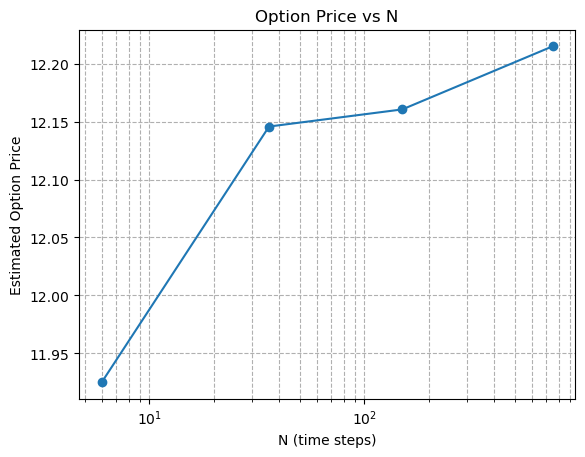

In [34]:
# Run the simulation for several N values
Ns = [6, 36, 150, 750]
results = []
for N in Ns:
    price, se = simulate_option_price(N, R=R, S0=S0, K=K, r=r, sigma=sigma, T=T, seed=0)
    results.append((N, price, se))
    print(f"N={N}: Point Estimate: {price:.4f}, SE: {se:.4f}, 95% CI: [{price-1.96*se:.4f}, {price+1.96*se:.4f}]")

# Optional: plot price vs N
try:
    import matplotlib.pyplot as plt
    plt.plot([r[0] for r in results], [r[1] for r in results], marker='o')
    plt.xlabel('N (time steps)')
    plt.ylabel('Estimated Option Price')
    plt.title('Option Price vs N')
    plt.xscale('log')
    plt.grid(True, which='both', ls='--')
    plt.show()
except Exception:
    pass


R=240, N=6: time=0.001s, price=11.6660
R=240, N=36: time=0.001s, price=11.2094
R=240, N=150: time=0.002s, price=10.9182
R=240, N=750: time=0.013s, price=11.7129
R=5000, N=6: time=0.001s, price=11.5638
R=5000, N=36: time=0.006s, price=12.2647
R=5000, N=150: time=0.028s, price=12.4905
R=5000, N=750: time=0.100s, price=12.2347
R=20000, N=6: time=0.003s, price=11.9029
R=20000, N=36: time=0.018s, price=12.2430
R=20000, N=150: time=0.077s, price=12.2016
R=20000, N=750: time=0.375s, price=12.2694
R=100000, N=6: time=0.018s, price=11.9964
R=100000, N=36: time=0.099s, price=12.1830
R=100000, N=150: time=0.390s, price=12.2074
R=100000, N=750: time=2.103s, price=12.1953
R=400000, N=6: time=0.085s, price=11.9403
R=400000, N=36: time=0.504s, price=12.1629
R=400000, N=150: time=2.198s, price=12.1799
R=400000, N=750: time=11.282s, price=12.2141


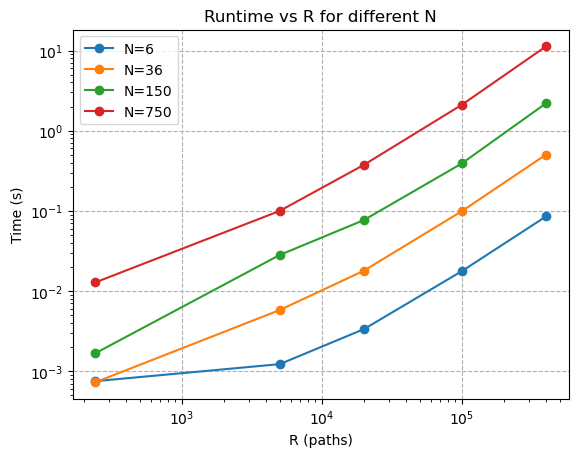

In [12]:
# Time the simulation for different R values and Ns
import time
Rs = [240, 5000, 20000, 100000, 400000]
Ns = [6, 36, 150, 750]
timings = []
for R in Rs:
    row = [R]
    for N in Ns:
        t0 = time.perf_counter()
        price, se = simulate_option_price(N, R=R, S0=S0, K=K, r=r, sigma=sigma, T=T, seed=0)
        dt = time.perf_counter() - t0
        row.append(dt)
        print(f"R={R}, N={N}: time={dt:.3f}s, price={price:.4f}")
    timings.append(row)


for i, N in enumerate(Ns):
    plt.plot([r[0] for r in timings], [r[i+1] for r in timings], marker='o', label=f'N={N}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('R (paths)')
plt.ylabel('Time (s)')
plt.title('Runtime vs R for different N')
plt.legend()
plt.grid(True, ls='--')
plt.show()
